# Analyzing Public Perception of DeepSeek on Reddit: A Text-Based Exploration

# Introduction

The rise of DeepSeek and other large language models (LLMs) marks both a technological milestone and an opportunity to explore the geopolitical and cultural tensions in the global AI landscape. It is important to examine how predominantly English-speaking social media platforms, particularly Reddit, shape perceptions of AI models like DeepSeek (developed in China) and ChatGPT (developed in the U.S.). In this task, we ask the question: **What narratives emerge from Reddit communities’ discussions about DeepSeek, and how do these narratives reflect user perceptions and sentiment of AI innovation?**




# Overview
In this assignment, we will practice text analysis with the following guided tasks:

1) **Task 1**: Apply **K-means** clustering to identify hidden groups within the data

2) **Task 2**: Conduct **sentiment analysis** to examine user emotions toward "DeepSeek"

3) **Task 3**: Perform **topic modeling** to uncover latent topics regarding "DeepSeek"



# Data
Reddit offers an open and unfiltered platform where individuals share their perceptions about AI techniques, making it an ideal source of authentic data. We download subreddit posts on DeepSeek (r/DeepSeek_posts) from [arctic-shift](https://arctic-shift.photon-reddit.com/).

In [75]:
import os,datetime
import json, csv
import re
import pandas as pd
import numpy as np
from collections import Counter
import pprint

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
from matplotlib.dates import DateFormatter

import warnings
warnings.filterwarnings('ignore')

In [76]:
import nltk
from nltk.corpus import words

nltk.download('words')
english_words = set(words.words())

[nltk_data] Downloading package words to
[nltk_data]     C:\Users\uprig\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!


# Exploratory Data Analysis

In [77]:
def load_data(data_file):
    """
    Load original data from jsonl file, clean the data, and convert to a dataframe
    """

    # Step 1: Read json file, store as list of dicts
    posts_lst = []
    with open(data_file, 'r', encoding='utf-8') as file:
        for line in file:
            posts_lst.append(json.loads(line))

    # Step 2: Extract fields that contain key information
    fields_to_extract = ['permalink', 'created_utc', 'selftext', 'title']

    # Step 3: Store the extracted information in a Dataframe
    extracted_data = [{k: d[k] for k in fields_to_extract if k in d} for d in posts_lst]
    df = pd.DataFrame(extracted_data)

    # Step 4: Complete each field of the dataframe
    df['permalink'] = 'https://old.reddit.com' + df['permalink']
    # Convert the unix timestamp to readable date
    df['date'] = df['created_utc'].apply(lambda x: datetime.datetime.utcfromtimestamp(x).strftime('%Y-%m-%d'))
    del df['created_utc']

    # Step 5: Remove rows with missing values
    df.dropna(how = 'any', inplace=True)
    df = df[df['selftext'] != '[removed]']
    df.rename(columns={'selftext':'post'}, inplace=True)

    # Step 6: Convert dtype: object to string
    df = df.convert_dtypes()

    return df

In [78]:
def clean_text(text):
    '''
    Cleans the input text by removing URLs, HTML tags, mentions, hashtags,
    punctuation, special characters, newlines, and extra spaces.

    Input:
        text: a string containing raw text.
    Output:
        cleaned_text: a string with cleaned text.
    '''
    # Remove URLs
    text = re.sub(r'https?://\S+', '', text)
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove mentions (@username) and hashtags (#hashtag)
    text = re.sub(r'[@#]\w+', '', text)
    # Remove punctuation and special characters, replace with space
    text = re.sub(r'[^\w\s]', ' ', text)
    # Replace newlines with spaces
    text = text.replace('\n', ' ')
    # Replace multiple spaces with a single space
    text = re.sub(r'\s+', ' ', text)
    # Remove leading/trailing spaces
    text = text.strip()

    # Remove non-English words
    text = ' '.join(word for word in text.split() if word.lower() in english_words)

    return text

In [79]:
# load and clean the post

df_post = load_data("C:/Users/uprig/Documents/Class/MACS33002/RedditUnsupervised/rDeepSeekposts.jsonl")
df_post['post'] = df_post['post'].apply(lambda x: clean_text(x))
df_post.shape

(7051, 4)

In [80]:
# check the first 5 rows of the dataframe
df_post.head()

,permalink,post,title,date
0,https://old.reddit.com/r/DeepSeek/comments/1do...,,What's the max tokens for deepseek-coder-v2?,2024-06-25
1,https://old.reddit.com/r/DeepSeek/comments/1eo...,Seriously super factual and level performance,DeepSeek Coder V2 is a beast!,2024-08-10
2,https://old.reddit.com/r/DeepSeek/comments/1fd...,anyone tried to get it working in Dev I m gett...,Integrating with Claude-Dev,2024-09-10
3,https://old.reddit.com/r/DeepSeek/comments/1fw...,I have a question that i cant seem to find yet...,How to simultaneously complete a LLMs workload...,2024-10-04
4,https://old.reddit.com/r/DeepSeek/comments/1gc...,I was chatting through coder but today upon a ...,What happened to Coder DeepSeek?,2024-10-26


In [81]:
# check the words counts of the posts
df_post['length'] = df_post['post'].apply(lambda x: len(x))
df_post['length'].describe()

count     7051.000000
mean       277.872075
std        963.601044
min          0.000000
25%          0.000000
50%         34.000000
75%        204.000000
max      26991.000000
Name: length, dtype: float64

In [82]:
# remove samples with post length = 0, almost half of the samples are removed
df_post = df_post[df_post['length'] != 0]
df_post.shape

(3907, 5)

Text(0.5, 1.0, 'Distribution of Word Counts in Each Post')

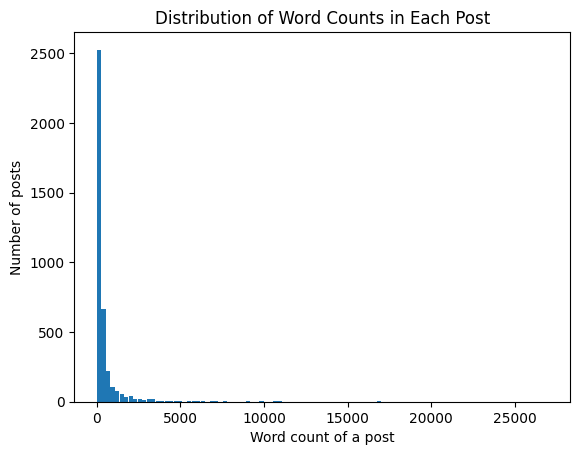

In [83]:
# check the word count distribution of the posts
plt.hist(df_post['length'].sort_values().values, bins=100, rwidth=0.9)
plt.xlabel("Word count of a post")
plt.ylabel("Number of posts")
plt.title("Distribution of Word Counts in Each Post")

In [84]:
# based on the distribution of word counts, we remove samples with word counts >= 6500
df_post = df_post[df_post['length'] < 6500]
df_post.shape

(3874, 5)

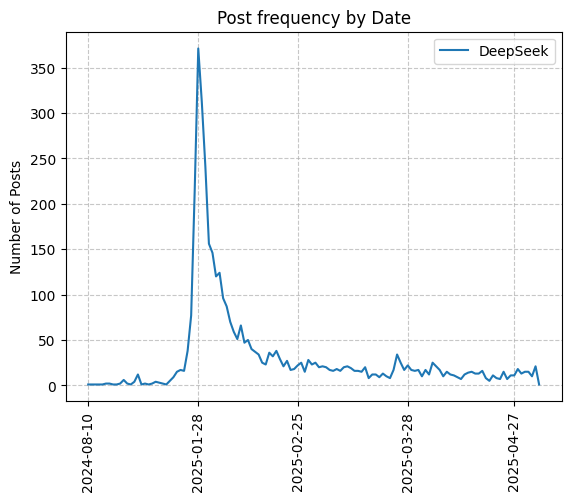

In [85]:
# visualize the post frequency
df_group = df_post.groupby(['date'])
df_bydate = df_group['post'].count().reset_index()

plt.plot(df_bydate['date'], df_bydate['post'], marker=None, linestyle='-', label='DeepSeek')

plt.title('Post frequency by Date')
plt.ylabel('Number of Posts')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
# symplify the x labels
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
# rotate tickers
plt.xticks(rotation=90)
plt.show()

**Discussion Q0**: Based on the plot, there's a noticeable peak in the post frequency. Can you explain why this occurred? (hint: Consider relevent developments in AI around that period).

The peak on January 28, 2025, reflects a significant release of DeepSeek: DeepSeek-R1. This was considered a groundbreaking development in AI and led to a drop in US stocks. Previously, China had been unable to compete with ChatGPT and this product was on par with ChatGPT and cheaper. Due to the significance of this event, it follows that there would be a spike in post frequency. After the peak, the frequency evens out but it is slightly higher than before, which represents the continued effects of the development. 

Citation: https://www.reuters.com/technology/artificial-intelligence/what-is-deepseek-why-is-it-disrupting-ai-sector-2025-01-27/#:~:text=HOW%20DOES%20BEIJING%20VIEW%20DEEPSEEK,by%20Baidu%20CEO%20Robin%20Li. 

# Tasks to complete
In the previous section, we load and clean our Reddit posts before exploring the word counts distribution of the posts. In the following section, we will apply two different unsupervised learning methods to cluster the posts and identify hidden topics, and apply a pretrained supervised learning model to predict public emotions. Recall the difference between supervised and unsupervised learning:
- In supervised learning, we train the model with labeled data, and then apply the model to predict labels for future data;
- In unsupervised learning, we work with unlabled data, aiming to identify hidden patterns or underlying structures of the data.

# Task-1: K-Means Clustering

In this task, you will apply k-means clustering to group the posts into clusters. Specifically, you will:
- Represent each post with a vector (e.g. by using `CountVectorizer`, `TfidfVectorizer`, an OpenAI embedding, or other strategies);
- Fit K-means models for each of a range of possible k's (e.g. `for k in range(2, 10)`), and calculate the `mean_squared_error` (MSE) for each fitted model;
  - Recall that the `MSE` for each cluster is calculated as the average difference between the cluster center and each data point in the cluster
  - Additionally recall that the `MSE` for the K-means model overall is the average MSE of all the generated clusters
- Visualize how the MSE changes with k (as in the example plot below). Identify **elbow points** fom the plot, and explain the best k in context of the given task.


Here is an example MSE plot.

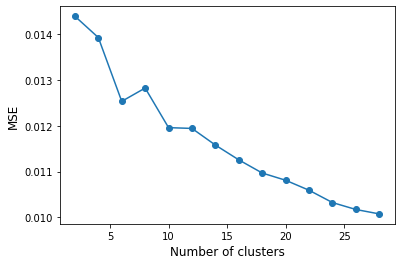

In [86]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error

In [87]:
# Initialize a TfidfVectorizer
vectorizer_tfidf = TfidfVectorizer(lowercase=True, max_df=0.9, min_df=3, ngram_range=(1,1))

# convert the cleaned text to vectors
X_tfidf = vectorizer_tfidf.fit_transform(df_post["post"])

In [88]:
mse = []
n = X_tfidf.shape[0]
for i in range(2,21): 
    kmeans = KMeans(n_clusters=i, random_state=0, n_init=10).fit(X_tfidf)
    mse.append(kmeans.inertia_ / n)

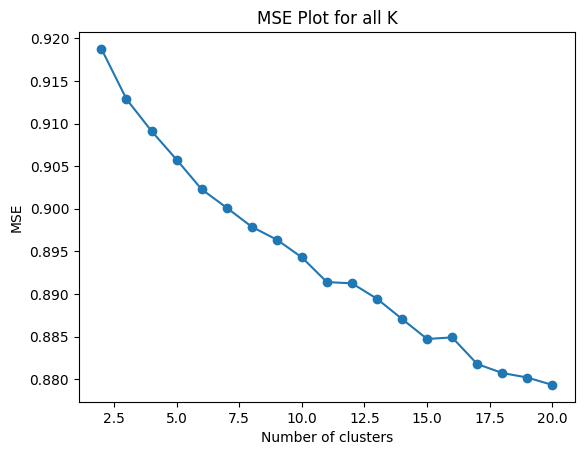

In [89]:
x = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
plt.plot(x,mse, marker='o')
plt.title('MSE Plot for all K')
plt.xlabel('Number of clusters')
plt.ylabel('MSE')
plt.show()

**Discussion Q1: Explain the selected k in the context of the given task.** That is, which value of k would you choose based on the produced plot?  Why do you select that k? What does this mean in the context of our Reddit posts?

The best k for this task is 11. There are elbow joint at 11, 15, and 17. I chose 11 clusters as the best because the least number of clusters that is optimal is best. None of the elbow points are as strong as ideal, but they do demonstrate some leveling off. In the context of the Reddit posts, this means that there are many subgroups of Reddit posts since there are a high number of clusters. The posts are separated into many groups based on the important words used, which could indicate that there are many different subtopics eing discussed regarding DeepSeek; for example, one group of posts may be about the economic effects, while another group is about the social effects, and another group talks about how to use the tool well. The different topics relates to the different important words being used. 

# Task-2: Sentiment Analysis

In this task, you will conduct sentiment analysis to examine user emotions toward when discussing DeepSeek on Reddit. You can choose to do it with [`vader SentimentIntensityAnalyzer`](https://github.com/cjhutto/vaderSentiment) or [`SamLowe/roberta-base-go_emotions`](https://huggingface.co/SamLowe/roberta-base-go_emotions).


If you choose to apply `vader SentimentIntensityAnalyzer`, then you need to do two broad steps:
1. Preprocess each post:
  - Remove English stopwords;
  - lemmatize each token;
  - Create a joint string of lemmatized tokens;
2. Run the model:
  - Initialize the `SentimentIntensityAnalyzer`;
  - Calculate the `polarity_score` of each processed post;
  - Extract the `compound` field from the `polarity_score` and record them in the new field `vader_sentiment`.

If you choose `SamLowe/roberta-base-go_emotions`, the specific steps are:
1. Apply `transformers.pipeline` to initialize a sentiment classifier from the model `SamLowe/roberta-base-go_emotions`, and apply it to predict emotions (note: the maximum text length the model can process is 514);
2. Record the 28 emotions and corresponding scores in the new field `roberta_multi_scores`;
3. Extract the emotions with a score >= 0.3, and record them in the new field `roberta_emotions`;
4. Save all the emotions in a list, sort the emotions by frequency descending order.



**Regardless of which model you apply, after conducting the sentiment analysis**, please:
1. Plot the sentiment distribution
  - If using the `roberta` model, this can be a bar plot; if using `vader`, this can be a density plot.
2. Visualize the sentiment change over time;
3. Discuss the sentiment distribution and sentiment change over time in the context of the given task.

Examples of all visuals can be seen below.

Example sentiment distribution plot using **Vader**:

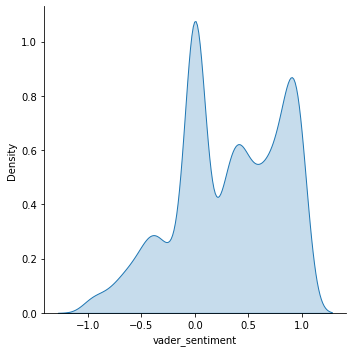

Example sentiment distribution plot using **Roberta**:

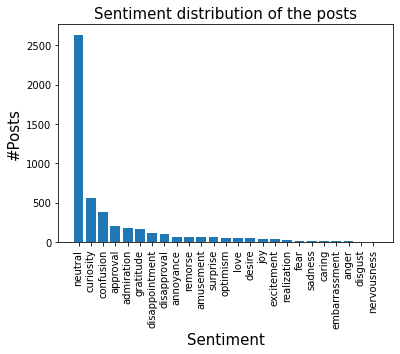

Example plot for **sentiment change over time**:

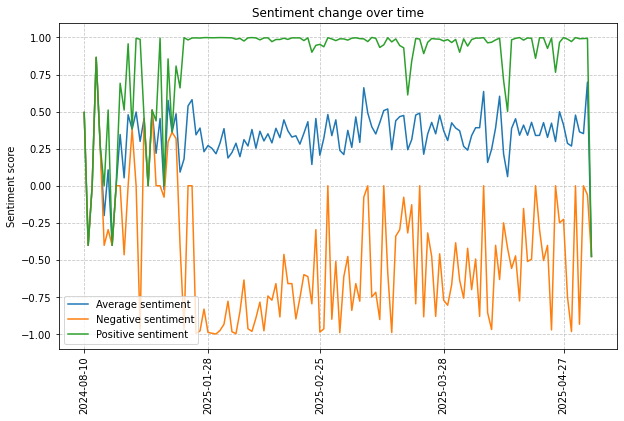

In [90]:
## Uncomment the relevant imports from below.

## Libraries you will need if using Vader
# import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')
## Libraries you will need if using Roberta
# import transformers
# from transformers import pipeline

# print(transformers.__version__)

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\uprig\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\uprig\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\uprig\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\uprig\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [91]:
def preprocess_text(text):
    tokens = word_tokenize(text.lower())
    filtered_tokens = [t for t in tokens if t not in stopwords.words('english')]
    lemmatizer = WordNetLemmatizer()
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in filtered_tokens]
    processed_text = ' '.join(lemmatized_tokens)
    return processed_text

In [92]:
analyzer = SentimentIntensityAnalyzer()
vader_sentiment = []

for post in df_post["post"]:
    post_by_token = preprocess_text(post)
    vader_sentiment.append(float("%.3f" % analyzer.polarity_scores(post_by_token)['compound']))

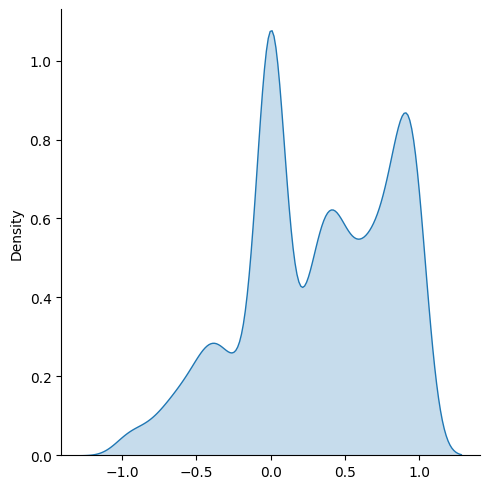

In [93]:
sns.displot(vader_sentiment, kind = 'kde', fill = True)

In [94]:
df_post["vader_sentiment"] = vader_sentiment

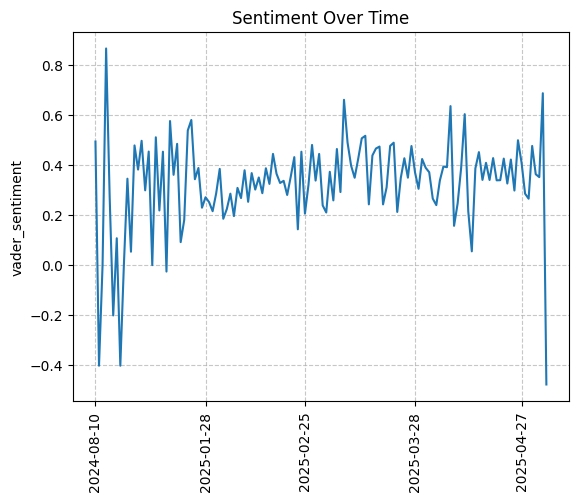

In [95]:
# Plot sentiment change over time
df_bydate = df_post.groupby('date')['vader_sentiment'].mean().reset_index()

plt.plot(df_bydate['date'], df_bydate['vader_sentiment'], marker=None, linestyle='-')

plt.title('Sentiment Over Time')
plt.ylabel('vader_sentiment')
plt.grid(True, linestyle='--', alpha=0.7)
# simplify the x labels
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
# rotate tickers
plt.xticks(rotation=90)
plt.show()

**Discussion Q2: What do you conclude from the sentiment distribution and sentiment change over time?**

Vader_sentiment scores are interpreted as -0.5-0.5 as neutral, with higher scores as positive and lower scores as negative. The first plot has a peak at 0, meaning most posts have neutral sentiment. The plot overall is skewed left so more posts are positive. There are two peaks on the positive side of the spectrum. One at the positive end of the neutral section and a taller one at the positive section. This demonstrates that overall, Reddit posts on DeepSeek reflect positive sentiments about the technology. 

Considering the plot overtime, there is more variation between positive and negative sentiment at the beginning and end of the time period (espeically the beginning), while the middle of the time period has less variation. It makes sense that there would be more ambivalence when the technology is first introduced and people are still forming their opinions. As people become accustomed to the technology, over time, their opinions will become more neutral. The plot does show that even when sentiment was more evened out, there were spikes into positive or negative sentiment, which could reflect smaller controversies or randomness in personal experience with the technology. 

# Task-3: Topic analysis with LDA

In this task, you will perform LDA topic modeling to uncover latent topics on the `r/DeepSeek` subreddit. Specifically, you will:
- Clean the text by removing stopwords, punctuations, and normalize with WordNetLemmatizer;
- Represent each post as a list of tokens;
- Create a dictionary and document-term matrix;
- Fit a LDA model with `num_topics = 3`;
- Print the keywords for each topic;
- Visualize the topic distribution with `pyLDAvis` and interprete the visualization;
- Try different number of topics (e.g., `start=2, limit=40, step=3`), and calculate topic coherence of each model;
- Visualize the change of coherence score with the number of topics and identify the number of topics that gives the best coherence score;
- Re-fit the LDA model with the best number of topics, visualize the topic distribution, and interpete the visualization;

***Note:*** We have example visualizations below, but they are *very* fragile, and will disappear if the "run all" button is clicked in your notebook.

In [96]:
# In order to successfully run LDA, make sure the following packages satisfy the version requirement
# pyLDAvis >= 3.4.0
# pandas < 2.0 # pip install pandas==1.5.3
# gensim >= 4.0

In [97]:
from gensim import corpora
from gensim.models import LdaModel
import string
from pprint import pprint

import pyLDAvis
pyLDAvis.enable_notebook()

import pyLDAvis.gensim_models as gensimvis
from gensim.models.coherencemodel import CoherenceModel
print(pyLDAvis.__version__)

warnings.filterwarnings('ignore', category=DeprecationWarning)

3.4.0


In [98]:
stop_words_more = set(stopwords.words('english')).union(['b', 'r', 'e', 'u', 'k', 'w', 
                                                         'c', 'n', 'g', 'x', 'se', 'si', 'de', 
                                                         'la', 'en', 'ba', 'un', 'oh',
                                                        'would', 'could'])
def clean_text_more(text):
    # remove stopwords, punctuation, and normalize the corpus
    stop_free = " ".join([w for w in text.lower().split() if w not in stop_words_more])
    punc_free = "".join(w for w in stop_free if w not in set(string.punctuation))
    normalized = " ".join(lemma.lemmatize(word) for word in punc_free.split())
    return normalized

In [99]:
lemma = WordNetLemmatizer()
post_by_token = [clean_text_more(post).split() for post in df_post['post']]

In [100]:
id2word = corpora.Dictionary(post_by_token)
post_term_matrix = [id2word.doc2bow(post) for post in post_by_token]

In [101]:
len(id2word)

9460

In [102]:
# Fit a LDA model with n topics
lda = LdaModel(corpus = post_term_matrix, id2word = id2word, num_topics=3, random_state=0, passes=20, iterations=100)

In [103]:
# Keywords for each topic
pprint(lda.print_topics(num_topics=3, num_words=8))

[(0,
  '0.015*"ai" + 0.008*"human" + 0.006*"self" + 0.005*"one" + 0.005*"let" + '
  '0.005*"like" + 0.005*"answer" + 0.004*"time"'),
 (1,
  '0.021*"ai" + 0.013*"like" + 0.012*"model" + 0.010*"use" + 0.006*"data" + '
  '0.006*"time" + 0.006*"get" + 0.006*"know"'),
 (2,
  '0.014*"china" + 0.008*"like" + 0.005*"government" + 0.005*"censorship" + '
  '0.004*"answer" + 0.004*"let" + 0.004*"information" + 0.003*"people"')]


In [104]:
# Visualize the topic distribution
vis = gensimvis.prepare(lda, post_term_matrix, id2word)
pyLDAvis.display(vis)

In [105]:
def compute_coherence_values(dictionary, document_term_mt, tokenized_corpus, start=2, limit=40, step=3):
    """
    Compute c_v coherence socre for each model (how often each topic's top-N words appear together in the corpus)

    Parameters:
    ----------
    dictionary : the id2word dictionary used to fit LDA
    document_term_mt : document term matrix
    tokenized_corpus : a list of input documents and each document is represented by a list of tokens

    Returns:
    -------
    model_list : A list of LDA topic models
    coherence_values : Coherence values corresponding to the LDA model with respective number of topics
    """
    coherence_values = []
    model_list = []
    for num_topics in range(start, limit, step):
        lda = LdaModel(corpus = document_term_mt, id2word = id2word, num_topics=num_topics, random_state=0, passes=20)
        model_list.append(lda)
        coherencemodel = CoherenceModel(model=lda, texts=tokenized_corpus, dictionary=id2word, coherence='c_v')
        coherence_values.append(coherencemodel.get_coherence())

    return model_list, coherence_values

In [106]:
# try different number of topics, and evaluate the coherence of the generated topics
model_list, coherence_values = compute_coherence_values(dictionary=id2word, document_term_mt=post_term_matrix,
                                                        tokenized_corpus=post_by_token, start=2, limit=40, step=4)

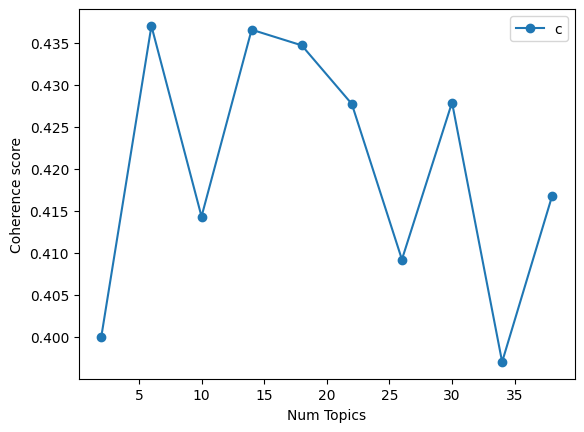

In [107]:
# visualize the coherence score for models with different #topics
limit=40; start=2; step=4;
x = range(start, limit, step)
plt.plot(x, coherence_values,'o-')
plt.xlabel("Num Topics")
plt.ylabel("Coherence score")
plt.legend(("coherence_values"), loc='best')
plt.show()

In [109]:
# Here is the expected topic coherence visualization:

**Discussion Q3.1: according to the plot, identify the optimal number of topics for the given task, and provide your explaination.**

Based on the plot, 6 topics is the optimal number as it has the highest coherence score. 15 is the next highest score. It is better to have less topics because they won't seem as similar to one another when comparing two numbers with similar coherence scores. 

NOTE: Before removing more stop words, 10 topics had the highest coherence score. This number of topics is similar to the k found in the clustering tax (k = 11). This coincides with the theory presented in that section: the important words of TfidfVectorizer used for clustering reflected topics of discussion in the Reddit posts. 

Apply the chosen **best number of topics to re-fit LDA**, visualize & explore it here.

In [110]:
# Re-fit the LDA model with the optimal number of topics and visualize the topic distribution
best_lda = LdaModel(corpus = post_term_matrix, id2word = id2word, num_topics=6, random_state=0, passes=20)

In [111]:
vis = gensimvis.prepare(best_lda, post_term_matrix, id2word)
pyLDAvis.display(vis)

**Discussion Q3.2: Based on the generated plots, characterize the topic distribution. What do the keywords for each topic tell us about the topics? If you had to assign names to the topics, what would they be? Lastly, what do the observed topic distributions tell us about the r/DeepSeek subreddit?**

The first plot with three cateogries reflects the overall topic distribution, which ranges from troubleshooting, technical, existential, and political concerns. In the first plot, I would label the topics as the following: 1) Use and troubleshooting, 2) Geo-political issues, and 3) the ethics of AI. For the six topic plot, I assign the following names: Use and troubleshooting (1, 3), Geo-political concerns (2), ethics and existential views on AI (6), and technical/mathematical/algorithmic perspectives (4). The plotting reflects how topics are similar to one another. For example, topic 5 is the most difficult to classify, and it is near the center. It seems to be a cross between the usage topics (1, 3) and the ethics topic (6). 
 
I used keywords to determine these categories. The geo-political topics were easiest to characterize. Some examples of keywords for this topic are "china", "censoring", "musk", "government" and "security". Keywords for troubleshooting include "please", "question", "try", "error" and "issue". The ethics and existential topics include keywords such as "consciousness", "intelligience", "existence", "ethical" and "god". Lastly, the technical categories include words such as "source", "efficiency", "data", "model" , "performance", and "training". 

The topic distributions demonstrate the range of topics that are talked about on the DeepSeek subreddit. Topic 1, which is about use, seems to be the largest, so people are most concerned about how the tool works. 2 and 3 are the next largest which reflects how people are concerned about personal troubleshooting and the geo-political implications of the product given US-China relations and state power competition. People are talking about ethical and existential concerns surrounding AI, but that is not the primary concern. There is also a smaller subpopulation of people concerned with talking about the more technical aspects of the product, as seen in topic 4. 

# Conclusion

In this assignment, we apply two different unsupervised learning methods to cluster the posts (`K-means`) and identify hidden topics (`LDA`), and apply a pretrained supervised learning model to predict public emotions (sentiment classifier).

Through these text analysis methods, we gain insights into users' opinions, usage, and deployment of AI. The identified insights could guide product designers, researchers, and software engineers seeking to find new and relevant use cases for LLMs.

Beyond the example exploration in this jupyter notebook, you can **extend it** in multiple different ways. For example:
- Compare sentiment and topic trends between posts and comments to see if they align or diverge.
- Analyze public perceptions of different AI innovations: examine how discussion topics and sentiments vary across different techniques.
- Explore additional dimensions such as temporal trends or emerging controversies to analyze the data.

Feel free to build on this foundation and uncover deeper insights.

##### AI Disclosure

I used AI for debugging code and interpretting python documentation.